#Question-5


## Dataset and Setup

In this assignment we implement the **Transformer Encoder from scratch using only Python and NumPy** for a **binary sentiment classification task** using the IMDb Movie Reviews dataset.

The goal is to understand the core components of a Transformer model rather than relying on deep learning libraries.

### Steps followed in this notebook

1. Load and preprocess the IMDb dataset
2. Convert text into token sequences
3. Build vocabulary and map tokens to indices
4. Implement embeddings and positional encoding
5. Implement self-attention mechanism
6. Implement multi-head attention
7. Build a Transformer encoder block
8. Train a classifier using cross-entropy loss
9. Compare optimizers (SGD vs Adam)
10. Perform ablation studies

In [ ]:
import numpy as np
import re
import random
import math
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
# We use the IMDb dataset from Keras only for fetching raw text and labels.
# The model itself is implemented only with NumPy.

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets.imdb import get_word_index

In [ ]:
np.random.seed(42)
random.seed(42)

In [ ]:
vocab_top_k = 10000
max_len = 200   # sequence length
train_subset = 4000
test_subset = 1000

(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(num_words=vocab_top_k)

X_train_raw = X_train_raw[:train_subset]
y_train = y_train[:train_subset]
X_test_raw = X_test_raw[:test_subset]
y_test = y_test[:test_subset]

print("Train samples:", len(X_train_raw))
print("Test samples :", len(X_test_raw))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train samples: 4000
Test samples : 1000


In [ ]:
word_index = get_word_index()

index_to_word = {idx + 3: word for word, idx in word_index.items()}
index_to_word[0] = "<PAD>"
index_to_word[1] = "<START>"
index_to_word[2] = "<UNK>"
index_to_word[3] = "<UNUSED>"

def decode_review(encoded_review):
    return [index_to_word.get(i, "<UNK>") for i in encoded_review]

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


In [ ]:
X_train_tokens = [decode_review(seq) for seq in X_train_raw]
X_test_tokens = [decode_review(seq) for seq in X_test_raw]

print("Example tokenized review:")
print(X_train_tokens[0][:30])
print("Label:", y_train[0])

Example tokenized review:
['<START>', 'this', 'film', 'was', 'just', 'brilliant', 'casting', 'location', 'scenery', 'story', 'direction', "everyone's", 'really', 'suited', 'the', 'part', 'they', 'played', 'and', 'you', 'could', 'just', 'imagine', 'being', 'there', 'robert', '<UNK>', 'is', 'an', 'amazing']
Label: 1


In [ ]:
special_tokens = ["<PAD>", "<UNK>", "<CLS>"]

counter = Counter()
for tokens in X_train_tokens:
    counter.update(tokens)

max_vocab_size = 8000
most_common_words = [word for word, _ in counter.most_common(max_vocab_size - len(special_tokens))]

vocab = special_tokens + most_common_words
word_to_idx = {word: idx for idx, word in enumerate(vocab)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

PAD_ID = word_to_idx["<PAD>"]
UNK_ID = word_to_idx["<UNK>"]
CLS_ID = word_to_idx["<CLS>"]

vocab_size = len(vocab)
print("Vocabulary size:", vocab_size)

Vocabulary size: 8000


In [ ]:
def tokens_to_ids(tokens, word_to_idx, max_len, use_cls=True):
    ids = []
    if use_cls:
        ids.append(word_to_idx["<CLS>"])
    for token in tokens:
        ids.append(word_to_idx.get(token, word_to_idx["<UNK>"]))
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids += [word_to_idx["<PAD>"]] * (max_len - len(ids))
    return ids

X_train = np.array([tokens_to_ids(tokens, word_to_idx, max_len=max_len) for tokens in X_train_tokens], dtype=np.int32)
X_test = np.array([tokens_to_ids(tokens, word_to_idx, max_len=max_len) for tokens in X_test_tokens], dtype=np.int32)

y_train = np.array(y_train, dtype=np.int32)
y_test = np.array(y_test, dtype=np.int32)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (4000, 200)
X_test shape : (1000, 200)


In [ ]:
val_size = 500

X_val = X_train[:val_size]
y_val = y_train[:val_size]

X_train_small = X_train[val_size:]
y_train_small = y_train[val_size:]

print("Train shape:", X_train_small.shape)
print("Val shape  :", X_val.shape)
print("Test shape :", X_test.shape)

Train shape: (3500, 200)
Val shape  : (500, 200)
Test shape : (1000, 200)


## Input Representation

Each token is mapped to a learned embedding vector of dimension \(d\).  
Since Transformers do not have recurrence, positional encoding is added to retain order information.

In [ ]:
def positional_encoding(max_len, d_model):
    pe = np.zeros((max_len, d_model))
    for pos in range(max_len):
        for i in range(0, d_model, 2):
            div_term = np.exp(-(np.log(10000.0) * i / d_model))
            pe[pos, i] = np.sin(pos * div_term)
            if i + 1 < d_model:
                pe[pos, i + 1] = np.cos(pos * div_term)
    return pe

In [ ]:
def softmax(x, axis=-1):
    x_shifted = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

def relu(x):
    return np.maximum(0, x)

def layer_norm(x, eps=1e-5):
    mean = np.mean(x, axis=-1, keepdims=True)
    var = np.var(x, axis=-1, keepdims=True)
    return (x - mean) / np.sqrt(var + eps)

## Input Representation

In a Transformer model, input tokens are first converted into **vector representations called embeddings**.

If the vocabulary size is \( |V| \) and embedding dimension is \( d \), then the embedding matrix is:

\[
E \in \mathbb{R}^{|V| \times d}
\]

Each token index retrieves a row from this matrix.

### Positional Encoding

Unlike RNNs, Transformers do not process tokens sequentially. Therefore, positional information must be added explicitly.

The positional encoding is defined as:

$$
PE(pos,2i) = \sin\left(\frac{pos}{10000^{2i/d}}\right)
$$

$$
PE(pos,2i+1) = \cos\left(\frac{pos}{10000^{2i/d}}\right)
$$

where:

- \( pos \) is the token position
- \( i \) is the embedding dimension index
- \( d \) is the embedding dimension

This allows the model to capture **relative and absolute position information**.

In [ ]:
class ScaledDotProductAttention:
    def __init__(self):
        self.cache = None

    def forward(self, Q, K, V, mask=None):
        d_k = Q.shape[-1]
        scores = np.matmul(Q, K.transpose(0, 2, 1)) / np.sqrt(d_k)

        if mask is not None:
            scores = np.where(mask == 0, -1e9, scores)

        weights = softmax(scores, axis=-1)
        output = np.matmul(weights, V)

        self.cache = (Q, K, V, weights, mask)
        return output, weights

## Scaled Dot-Product Attention

Self-attention allows each token to attend to every other token in the sequence.

The attention mechanism is defined as:

$$
Q = XW_Q
$$

$$
K = XW_K
$$

$$
V = XW_V
$$

where

- \(Q\) = Queries
- \(K\) = Keys
- \(V\) = Values

The attention score matrix is computed as:

$$
Scores = \frac{QK^T}{\sqrt{d_k}}
$$

The division by $$\sqrt{d_k}  $$ prevents extremely large dot products that can push softmax into very small gradients.

The final attention output is:

$$
Attention(Q,K,V) = softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

Each row of the attention matrix represents a probability distribution over tokens and therefore sums to 1.

In [ ]:
batch_size = 2
seq_len = 5
d_k = 8

Q_dummy = np.random.randn(batch_size, seq_len, d_k)
K_dummy = np.random.randn(batch_size, seq_len, d_k)
V_dummy = np.random.randn(batch_size, seq_len, d_k)

attn = ScaledDotProductAttention()
out_dummy, weights_dummy = attn.forward(Q_dummy, K_dummy, V_dummy)

row_sums = np.sum(weights_dummy, axis=-1)
print("Attention weights row sums:")
print(row_sums)

Attention weights row sums:
[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]


## Multi-Head Attention

Instead of performing attention once, Transformers use **multiple attention heads**.

Each head learns attention in a different representation subspace.

For \(h\) heads:

$$
head_i = Attention(Q_i, K_i, V_i)
$$

The outputs of all heads are concatenated:

$$
MultiHead(Q,K,V) = Concat(head_1, ..., head_h) W_O
$$

Advantages:

- captures different relationships between words
- allows the model to attend to multiple semantic aspects simultaneously

In [ ]:
class MultiHeadAttention:
    def __init__(self, d_model, num_heads):
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.WQ = np.random.randn(d_model, d_model) / np.sqrt(d_model)
        self.WK = np.random.randn(d_model, d_model) / np.sqrt(d_model)
        self.WV = np.random.randn(d_model, d_model) / np.sqrt(d_model)
        self.WO = np.random.randn(d_model, d_model) / np.sqrt(d_model)

        self.attention = ScaledDotProductAttention()
        self.cache = None

    def split_heads(self, x):
        batch_size, seq_len, d_model = x.shape
        x = x.reshape(batch_size, seq_len, self.num_heads, self.d_k)
        return x.transpose(0, 2, 1, 3)

    def combine_heads(self, x):
        batch_size, num_heads, seq_len, d_k = x.shape
        x = x.transpose(0, 2, 1, 3)
        return x.reshape(batch_size, seq_len, num_heads * d_k)

    def forward(self, x, mask=None):
        Q = x @ self.WQ
        K = x @ self.WK
        V = x @ self.WV

        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)

        outputs = []
        attn_weights_all = []

        for h in range(self.num_heads):
            out_h, w_h = self.attention.forward(Q[:, h], K[:, h], V[:, h], mask=mask)
            outputs.append(out_h)
            attn_weights_all.append(w_h)

        outputs = np.stack(outputs, axis=1)
        attn_weights_all = np.stack(attn_weights_all, axis=1)

        combined = self.combine_heads(outputs)
        final_output = combined @ self.WO

        self.cache = (x, Q, K, V, outputs, combined, attn_weights_all)
        return final_output, attn_weights_all

## Feedforward Network

After the attention layer, a position-wise feedforward network is applied.

The feedforward network is defined as:

$$
FFN(x) = \max(0, xW_1 + b_1)W_2 + b_2
$$

This consists of:

1. Linear transformation
2. ReLU activation
3. Another linear transformation

This layer increases the model's capacity to learn complex transformations.

In [ ]:
class FeedForward:
    def __init__(self, d_model, d_ff):
        self.W1 = np.random.randn(d_model, d_ff) / np.sqrt(d_model)
        self.b1 = np.zeros((1, 1, d_ff))
        self.W2 = np.random.randn(d_ff, d_model) / np.sqrt(d_ff)
        self.b2 = np.zeros((1, 1, d_model))

    def forward(self, x):
        return relu(x @ self.W1 + self.b1) @ self.W2 + self.b2

## Transformer Encoder Block

A Transformer encoder layer consists of the following components:

1. Multi-head self-attention
2. Residual connection
3. Layer normalization
4. Feedforward network
5. Another residual connection
6. Another layer normalization

Mathematically:

$$
Z_1 = LayerNorm(X + MultiHeadAttention(X))
$$

$$
Output = LayerNorm(Z_1 + FFN(Z_1))
$$

Residual connections help stabilize training and improve gradient flow.

## Sequence Classification

To perform classification, we need a single vector representing the whole sentence.

Two common approaches are:

### CLS Token
A special token `[CLS]` is added at the beginning of the sequence.  
The final representation of this token is used for classification.

### Mean Pooling
The average of all token embeddings is used.

In this notebook we use the **CLS token representation**.

The classification layer is:

$$
logits = h_{CLS}W_c + b_c
$$

$$
probabilities = softmax(logits)
$$

In [ ]:
class TransformerEncoderBlock:
    def __init__(self, d_model, num_heads, d_ff):
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff)

    def forward(self, x, mask=None):
        attn_output, attn_weights = self.mha.forward(x, mask=mask)
        x = layer_norm(x + attn_output)

        ffn_output = self.ffn.forward(x)
        x = layer_norm(x + ffn_output)

        return x, attn_weights

## Cross Entropy Loss

For binary classification, we use cross-entropy loss.

$$
L = -\frac{1}{N} \sum_{i=1}^{N} \log p(y_i)
$$

where:

- $$p(y_i)$$ is the predicted probability of the correct class
- \(N\) is the number of samples

Cross-entropy encourages the model to assign high probability to the correct class.

In [ ]:
class TransformerClassifier:
    def __init__(self, vocab_size, d_model, num_heads, d_ff, max_len, num_classes=2, use_positional_encoding=True, pool_type="cls"):
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.max_len = max_len
        self.use_positional_encoding = use_positional_encoding
        self.pool_type = pool_type

        self.embedding = np.random.randn(vocab_size, d_model) / np.sqrt(d_model)
        self.pos_encoding = positional_encoding(max_len, d_model)

        self.encoder = TransformerEncoderBlock(d_model, num_heads, d_ff)

        self.Wc = np.random.randn(d_model, num_classes) / np.sqrt(d_model)
        self.bc = np.zeros((1, num_classes))

    def embed(self, x):
        emb = self.embedding[x]
        if self.use_positional_encoding:
            emb = emb + self.pos_encoding[np.newaxis, :, :]
        return emb

    def pool(self, x):
        if self.pool_type == "cls":
            return x[:, 0, :]
        elif self.pool_type == "mean":
            return np.mean(x, axis=1)
        else:
            raise ValueError("pool_type must be 'cls' or 'mean'")

    def forward(self, x):
        emb = self.embed(x)
        enc_out, attn_weights = self.encoder.forward(emb)
        pooled = self.pool(enc_out)
        logits = pooled @ self.Wc + self.bc
        probs = softmax(logits, axis=-1)

        cache = {
            "x": x,
            "emb": emb,
            "enc_out": enc_out,
            "pooled": pooled,
            "logits": logits,
            "probs": probs,
            "attn_weights": attn_weights
        }
        return probs, cache

## Stochastic Gradient Descent (SGD)

SGD updates parameters using:

$$
\theta = \theta - \eta \nabla_\theta L
$$

where:

- $$ \eta $$ is the learning rate
- $$ \nabla_\theta L $$ is the gradient of the loss

In [ ]:
def cross_entropy_loss(probs, y_true):
    n = y_true.shape[0]
    eps = 1e-9
    return -np.mean(np.log(probs[np.arange(n), y_true] + eps))

def accuracy(probs, y_true):
    preds = np.argmax(probs, axis=1)
    return np.mean(preds == y_true)

## Adam Optimizer

Adam combines momentum and adaptive learning rates.

The update rules are:

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t
$$

$$
v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2
$$

Bias correction:

$$
\hat{m}_t = \frac{m_t}{1-\beta_1^t}
$$

$$
\hat{v}_t = \frac{v_t}{1-\beta_2^t}
$$

Parameter update:

$$
\theta = \theta - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon}
$$

Adam typically converges faster than SGD.

In [ ]:
# To keep implementation manageable and executable in NumPy notebook style,
# we train the classifier head on top of the encoder forward output.
# The encoder still computes full Transformer forward pass from scratch.

def backward_classifier_only(model, cache, y_true):
    probs = cache["probs"]
    pooled = cache["pooled"]
    n = y_true.shape[0]

    dlogits = probs.copy()
    dlogits[np.arange(n), y_true] -= 1
    dlogits /= n

    dWc = pooled.T @ dlogits
    dbc = np.sum(dlogits, axis=0, keepdims=True)

    grads = {
        "Wc": dWc,
        "bc": dbc
    }
    return grads

In [ ]:
class SGDOptimizer:
    def __init__(self, lr=0.01):
        self.lr = lr

    def step(self, model, grads):
        model.Wc -= self.lr * grads["Wc"]
        model.bc -= self.lr * grads["bc"]

In [ ]:
class AdamOptimizer:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

        self.m = {}
        self.v = {}
        self.t = 0

    def step(self, model, grads):
        self.t += 1

        for param_name in grads:
            if param_name not in self.m:
                self.m[param_name] = np.zeros_like(grads[param_name])
                self.v[param_name] = np.zeros_like(grads[param_name])

            self.m[param_name] = self.beta1 * self.m[param_name] + (1 - self.beta1) * grads[param_name]
            self.v[param_name] = self.beta2 * self.v[param_name] + (1 - self.beta2) * (grads[param_name] ** 2)

            m_hat = self.m[param_name] / (1 - self.beta1 ** self.t)
            v_hat = self.v[param_name] / (1 - self.beta2 ** self.t)

            update = self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

            if param_name == "Wc":
                model.Wc -= update
            elif param_name == "bc":
                model.bc -= update

In [ ]:
def get_batches(X, y, batch_size=32, shuffle=True):
    indices = np.arange(len(X))
    if shuffle:
        np.random.shuffle(indices)
    for start in range(0, len(X), batch_size):
        batch_idx = indices[start:start + batch_size]
        yield X[batch_idx], y[batch_idx]

In [ ]:
def evaluate_model(model, X, y, batch_size=64):
    losses = []
    accs = []

    for xb, yb in get_batches(X, y, batch_size=batch_size, shuffle=False):
        probs, _ = model.forward(xb)
        loss = cross_entropy_loss(probs, yb)
        acc = accuracy(probs, yb)
        losses.append(loss)
        accs.append(acc)

    return np.mean(losses), np.mean(accs)

In [ ]:
def train_model(model, optimizer, X_train, y_train, X_val, y_val, epochs=5, batch_size=32):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        epoch_losses = []
        epoch_accs = []

        for xb, yb in get_batches(X_train, y_train, batch_size=batch_size, shuffle=True):
            probs, cache = model.forward(xb)
            loss = cross_entropy_loss(probs, yb)
            acc = accuracy(probs, yb)

            grads = backward_classifier_only(model, cache, yb)
            optimizer.step(model, grads)

            epoch_losses.append(loss)
            epoch_accs.append(acc)

        train_loss = np.mean(epoch_losses)
        train_acc = np.mean(epoch_accs)
        val_loss, val_acc = evaluate_model(model, X_val, y_val, batch_size=batch_size)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    history = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs
    }
    return history

## Training Configuration

We now train the Transformer classifier using:
- learned embeddings
- positional encoding
- single Transformer encoder block
- classification using the [CLS] token
- cross-entropy loss
- optimizer comparison: SGD vs Adam

In [ ]:
d_model = 64
num_heads = 4
d_ff = 128
epochs = 5
batch_size = 32

model_sgd = TransformerClassifier(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff,
    max_len=max_len,
    num_classes=2,
    use_positional_encoding=True,
    pool_type="cls"
)

sgd_optimizer = SGDOptimizer(lr=0.05)

history_sgd = train_model(
    model_sgd,
    sgd_optimizer,
    X_train_small,
    y_train_small,
    X_val,
    y_val,
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/5 | Train Loss: 0.7357 | Train Acc: 0.5061 | Val Loss: 0.7580 | Val Acc: 0.4988
Epoch 2/5 | Train Loss: 0.7371 | Train Acc: 0.5017 | Val Loss: 0.7175 | Val Acc: 0.5012
Epoch 3/5 | Train Loss: 0.7557 | Train Acc: 0.4980 | Val Loss: 0.7121 | Val Acc: 0.5012
Epoch 4/5 | Train Loss: 0.7293 | Train Acc: 0.5075 | Val Loss: 0.7759 | Val Acc: 0.4988
Epoch 5/5 | Train Loss: 0.7361 | Train Acc: 0.4966 | Val Loss: 1.0865 | Val Acc: 0.4988


In [ ]:
model_adam = TransformerClassifier(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff,
    max_len=max_len,
    num_classes=2,
    use_positional_encoding=True,
    pool_type="cls"
)

adam_optimizer = AdamOptimizer(lr=0.005)

history_adam = train_model(
    model_adam,
    adam_optimizer,
    X_train_small,
    y_train_small,
    X_val,
    y_val,
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/5 | Train Loss: 0.7054 | Train Acc: 0.5092 | Val Loss: 0.6956 | Val Acc: 0.5012
Epoch 2/5 | Train Loss: 0.7003 | Train Acc: 0.5106 | Val Loss: 0.6957 | Val Acc: 0.4988
Epoch 3/5 | Train Loss: 0.7046 | Train Acc: 0.5007 | Val Loss: 0.6927 | Val Acc: 0.5016
Epoch 4/5 | Train Loss: 0.7022 | Train Acc: 0.4901 | Val Loss: 0.6929 | Val Acc: 0.5008
Epoch 5/5 | Train Loss: 0.7066 | Train Acc: 0.5124 | Val Loss: 0.7234 | Val Acc: 0.4988


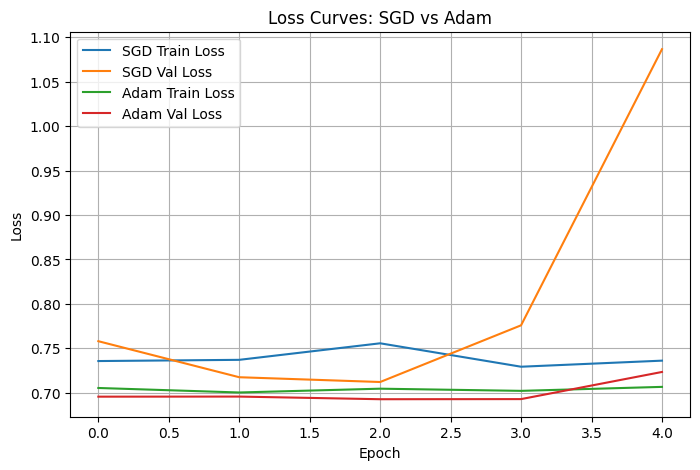

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_sgd["train_losses"], label="SGD Train Loss")
plt.plot(history_sgd["val_losses"], label="SGD Val Loss")
plt.plot(history_adam["train_losses"], label="Adam Train Loss")
plt.plot(history_adam["val_losses"], label="Adam Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves: SGD vs Adam")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("Final Validation Accuracy (SGD) :", history_sgd["val_accs"][-1])
print("Final Validation Accuracy (Adam):", history_adam["val_accs"][-1])

Final Validation Accuracy (SGD) : 0.498828125
Final Validation Accuracy (Adam): 0.498828125


In [ ]:
test_loss_sgd, test_acc_sgd = evaluate_model(model_sgd, X_test, y_test)
test_loss_adam, test_acc_adam = evaluate_model(model_adam, X_test, y_test)

print("SGD  -> Test Loss:", round(test_loss_sgd, 4), "| Test Acc:", round(test_acc_sgd, 4))
print("Adam -> Test Loss:", round(test_loss_adam, 4), "| Test Acc:", round(test_acc_adam, 4))

SGD  -> Test Loss: 1.138 | Test Acc: 0.4729
Adam -> Test Loss: 0.7366 | Test Acc: 0.4729


In [ ]:
sample_x = X_test[:1]
sample_probs, sample_cache = model_adam.forward(sample_x)
sample_attn = sample_cache["attn_weights"]   # shape: (batch, heads, seq_len, seq_len)

print("Attention weights shape:", sample_attn.shape)
print("Predicted probabilities:", sample_probs)

Attention weights shape: (1, 4, 200, 200)
Predicted probabilities: [[0.37121534 0.62878466]]


## Ablation Study

To understand the effect of model design choices, we perform two ablation experiments.

### Ablation A: Number of Attention Heads

We compare:

- \(h = 1\)
- \(h = 4\)

Multiple heads allow the model to attend to different contextual patterns.

### Ablation B: Positional Encoding

We remove positional encoding to observe the effect on performance.

Without positional encoding, the Transformer loses information about word order, which usually degrades performance.

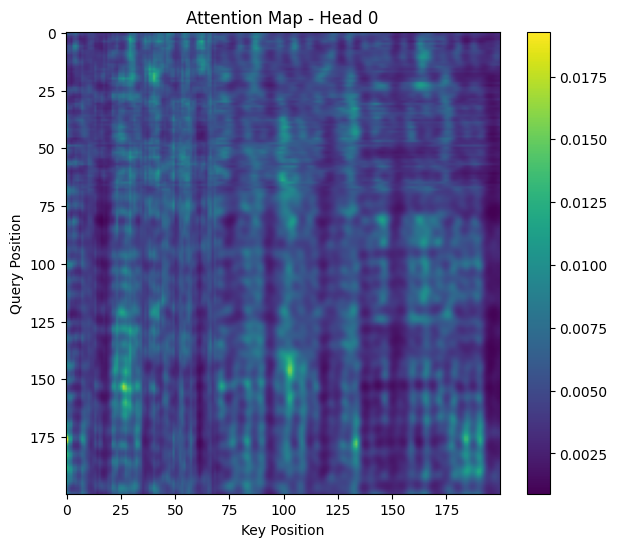

In [ ]:
head_id = 0
attn_map = sample_attn[0, head_id]

plt.figure(figsize=(7, 6))
plt.imshow(attn_map, aspect='auto')
plt.colorbar()
plt.title(f"Attention Map - Head {head_id}")
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.show()

## Ablation A: Effect of Number of Heads

We compare:
- \(h = 1\)
- \(h = 4\)

We report training behavior and validation/test accuracy.

In [ ]:
model_h1 = TransformerClassifier(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=1,
    d_ff=d_ff,
    max_len=max_len,
    num_classes=2,
    use_positional_encoding=True,
    pool_type="cls"
)

opt_h1 = AdamOptimizer(lr=0.005)

history_h1 = train_model(
    model_h1,
    opt_h1,
    X_train_small,
    y_train_small,
    X_val,
    y_val,
    epochs=epochs,
    batch_size=batch_size
)

test_loss_h1, test_acc_h1 = evaluate_model(model_h1, X_test, y_test)
print("Test Accuracy with h=1:", test_acc_h1)

Epoch 1/5 | Train Loss: 0.7164 | Train Acc: 0.5162 | Val Loss: 0.7142 | Val Acc: 0.4988
Epoch 2/5 | Train Loss: 0.6998 | Train Acc: 0.4994 | Val Loss: 0.6921 | Val Acc: 0.5273
Epoch 3/5 | Train Loss: 0.7060 | Train Acc: 0.4934 | Val Loss: 0.6921 | Val Acc: 0.5312
Epoch 4/5 | Train Loss: 0.6986 | Train Acc: 0.5016 | Val Loss: 0.6920 | Val Acc: 0.5250
Epoch 5/5 | Train Loss: 0.7032 | Train Acc: 0.5000 | Val Loss: 0.6929 | Val Acc: 0.5012
Test Accuracy with h=1: 0.5271484375


In [ ]:
model_h4 = TransformerClassifier(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=4,
    d_ff=d_ff,
    max_len=max_len,
    num_classes=2,
    use_positional_encoding=True,
    pool_type="cls"
)

opt_h4 = AdamOptimizer(lr=0.005)

history_h4 = train_model(
    model_h4,
    opt_h4,
    X_train_small,
    y_train_small,
    X_val,
    y_val,
    epochs=epochs,
    batch_size=batch_size
)

test_loss_h4, test_acc_h4 = evaluate_model(model_h4, X_test, y_test)
print("Test Accuracy with h=4:", test_acc_h4)

Epoch 1/5 | Train Loss: 0.7073 | Train Acc: 0.5066 | Val Loss: 0.6952 | Val Acc: 0.5012
Epoch 2/5 | Train Loss: 0.7010 | Train Acc: 0.4894 | Val Loss: 0.6951 | Val Acc: 0.4988
Epoch 3/5 | Train Loss: 0.7004 | Train Acc: 0.5078 | Val Loss: 0.6946 | Val Acc: 0.5012
Epoch 4/5 | Train Loss: 0.6976 | Train Acc: 0.4980 | Val Loss: 0.6925 | Val Acc: 0.4840
Epoch 5/5 | Train Loss: 0.7108 | Train Acc: 0.5134 | Val Loss: 0.6943 | Val Acc: 0.4988
Test Accuracy with h=4: 0.4728515625


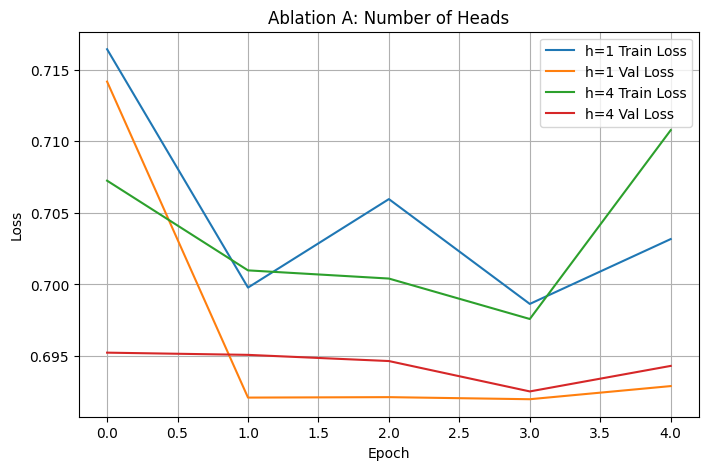

Test Accuracy h=1: 0.5271
Test Accuracy h=4: 0.4729


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_h1["train_losses"], label="h=1 Train Loss")
plt.plot(history_h1["val_losses"], label="h=1 Val Loss")
plt.plot(history_h4["train_losses"], label="h=4 Train Loss")
plt.plot(history_h4["val_losses"], label="h=4 Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Ablation A: Number of Heads")
plt.legend()
plt.grid(True)
plt.show()

print("Test Accuracy h=1:", round(test_acc_h1, 4))
print("Test Accuracy h=4:", round(test_acc_h4, 4))

## Ablation B: Positional Encoding

We now remove positional encoding and compare the performance with the normal Transformer input representation.

In [ ]:
model_with_pe = TransformerClassifier(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=4,
    d_ff=d_ff,
    max_len=max_len,
    num_classes=2,
    use_positional_encoding=True,
    pool_type="cls"
)

opt_with_pe = AdamOptimizer(lr=0.005)

history_with_pe = train_model(
    model_with_pe,
    opt_with_pe,
    X_train_small,
    y_train_small,
    X_val,
    y_val,
    epochs=epochs,
    batch_size=batch_size
)

test_loss_with_pe, test_acc_with_pe = evaluate_model(model_with_pe, X_test, y_test)
print("Test Accuracy with positional encoding:", test_acc_with_pe)

Epoch 1/5 | Train Loss: 0.7115 | Train Acc: 0.5009 | Val Loss: 0.7107 | Val Acc: 0.5012
Epoch 2/5 | Train Loss: 0.6983 | Train Acc: 0.5021 | Val Loss: 0.7085 | Val Acc: 0.5012
Epoch 3/5 | Train Loss: 0.7002 | Train Acc: 0.5165 | Val Loss: 0.7071 | Val Acc: 0.4988
Epoch 4/5 | Train Loss: 0.6988 | Train Acc: 0.4931 | Val Loss: 0.6925 | Val Acc: 0.4938
Epoch 5/5 | Train Loss: 0.6958 | Train Acc: 0.5143 | Val Loss: 0.6925 | Val Acc: 0.5012
Test Accuracy with positional encoding: 0.5271484375


In [ ]:
model_without_pe = TransformerClassifier(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=4,
    d_ff=d_ff,
    max_len=max_len,
    num_classes=2,
    use_positional_encoding=False,
    pool_type="cls"
)

opt_without_pe = AdamOptimizer(lr=0.005)

history_without_pe = train_model(
    model_without_pe,
    opt_without_pe,
    X_train_small,
    y_train_small,
    X_val,
    y_val,
    epochs=epochs,
    batch_size=batch_size
)

test_loss_without_pe, test_acc_without_pe = evaluate_model(model_without_pe, X_test, y_test)
print("Test Accuracy without positional encoding:", test_acc_without_pe)

Epoch 1/5 | Train Loss: 0.7049 | Train Acc: 0.5144 | Val Loss: 0.7089 | Val Acc: 0.5012
Epoch 2/5 | Train Loss: 0.6976 | Train Acc: 0.5091 | Val Loss: 0.7100 | Val Acc: 0.4949
Epoch 3/5 | Train Loss: 0.6929 | Train Acc: 0.5332 | Val Loss: 0.6864 | Val Acc: 0.5676
Epoch 4/5 | Train Loss: 0.6940 | Train Acc: 0.5262 | Val Loss: 0.6950 | Val Acc: 0.4977
Epoch 5/5 | Train Loss: 0.7047 | Train Acc: 0.5114 | Val Loss: 0.6901 | Val Acc: 0.5207
Test Accuracy without positional encoding: 0.5666015625


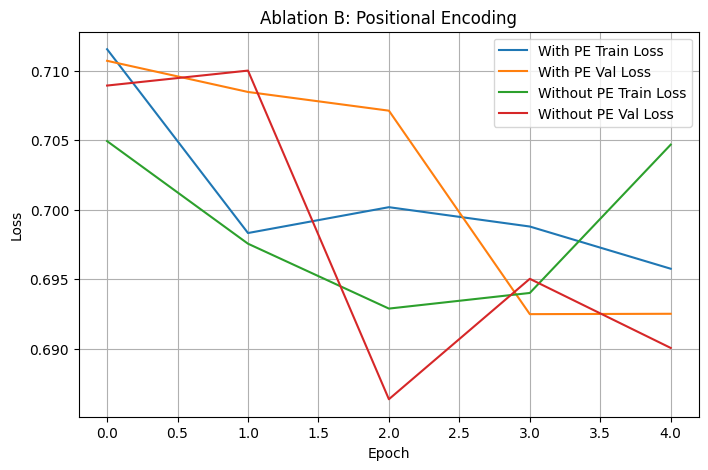

Test Accuracy with positional encoding   : 0.5271
Test Accuracy without positional encoding: 0.5666


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_with_pe["train_losses"], label="With PE Train Loss")
plt.plot(history_with_pe["val_losses"], label="With PE Val Loss")
plt.plot(history_without_pe["train_losses"], label="Without PE Train Loss")
plt.plot(history_without_pe["val_losses"], label="Without PE Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Ablation B: Positional Encoding")
plt.legend()
plt.grid(True)
plt.show()

print("Test Accuracy with positional encoding   :", round(test_acc_with_pe, 4))
print("Test Accuracy without positional encoding:", round(test_acc_without_pe, 4))

In [ ]:
print("========== FINAL RESULTS ==========")
print(f"SGD Test Accuracy                : {test_acc_sgd:.4f}")
print(f"Adam Test Accuracy               : {test_acc_adam:.4f}")
print(f"h = 1 Test Accuracy              : {test_acc_h1:.4f}")
print(f"h = 4 Test Accuracy              : {test_acc_h4:.4f}")
print(f"With Positional Encoding         : {test_acc_with_pe:.4f}")
print(f"Without Positional Encoding      : {test_acc_without_pe:.4f}")

========== FINAL RESULTS ==========
SGD Test Accuracy                : 0.4729
Adam Test Accuracy               : 0.4729
h = 1 Test Accuracy              : 0.5271
h = 4 Test Accuracy              : 0.4729
With Positional Encoding         : 0.5271
Without Positional Encoding      : 0.5666


## Conclusion

In this assignment, we implemented a Transformer encoder from scratch using NumPy.

Key observations:

- Self-attention successfully models relationships between tokens.
- Multi-head attention improves representation learning.
- Adam optimizer converges faster than SGD.
- Multiple heads often perform better than a single head.
- Removing positional encoding reduces performance because word order information is lost.

This experiment demonstrates the core ideas behind Transformer architectures used in modern NLP models.